In [ ]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
import seaborn as sns
from tqdm import tqdm
from collections import OrderedDict


In [ ]:
NUM_CLASSES = 3
BATCH_SIZE = 64 
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
WARMUP_EPOCHS = 5
IMAGE_SIZE = 224
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Update these paths to the dataset locations
RESNET_WEIGHTS_PATH = '/kaggle/input/datasets/adman007/pretrained-models/phy_effnet_b0_best.pt'
EFFNET_WEIGHTS_PATH = '/kaggle/input/datasets/adman007/pretrained-models/best_efficientNet_b0_classification_model.pt'


In [ ]:

class LensingLayer(nn.Module):
    def __init__(self, img_size=224):
        super(LensingLayer, self).__init__()
        self.img_size = img_size
        x = torch.linspace(-1, 1, img_size)
        y = torch.linspace(-1, 1, img_size)
        grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
        self.register_buffer('grid', torch.stack((grid_y, grid_x), dim=-1).unsqueeze(0)) 

    def forward(self, x, alpha):
        batch_size = x.size(0)
        # Scale shift by 0.05 
        shift = (alpha * 0.05).view(batch_size, 1, 1, 2) 
        recon_grid = self.grid.expand(batch_size, -1, -1, -1) - shift
        # Use border padding to eliminate artifacts
        source_recon = nn.functional.grid_sample(x, recon_grid, align_corners=True, padding_mode='border')
        return source_recon

class PINNLensingModelHybrid(nn.Module):
    def __init__(self):
        super(PINNLensingModelHybrid, self).__init__()
        
        # 1. Encoder (ResNet-34)
        self.parameter_encoder = models.resnet34(weights=None)
        self.parameter_encoder.fc = nn.Linear(self.parameter_encoder.fc.in_features, 2)
        
        self.lensing_layer = LensingLayer(img_size=IMAGE_SIZE)
        
        # 2. Classifier (EfficientNet-B0)
        self.classifier = models.efficientnet_b0(weights=None)
        
        original_conv = self.classifier.features[0][0]
        self.classifier.features[0][0] = nn.Conv2d(
            6, original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )
        self.classifier.classifier[1] = nn.Linear(self.classifier.classifier[1].in_features, NUM_CLASSES)

    def forward(self, x):
        alpha = self.parameter_encoder(x)
        source_recon = self.lensing_layer(x, alpha)
        combined_input = torch.cat((x, source_recon), dim=1) # [B, 6, H, W]
        return self.classifier(combined_input)



def load_custom_weights(model, resnet_path, effnet_path):
    
    if os.path.exists(resnet_path):
        print(f"Loading ResNet-34 weights from: {resnet_path}")
        res_state = torch.load(resnet_path, map_location=DEVICE)
        res_new_state = OrderedDict()
        for k, v in res_state.items():
            if 'parameter_encoder' in k:
                name = k.replace("_orig_mod.", "") # Clean compile artifacts if any
                res_new_state[name] = v
        model.load_state_dict(res_new_state, strict=False)
    
    
    if os.path.exists(effnet_path):
        print(f"Loading EfficientNet-B0 weights from: {effnet_path}")
        eff_state = torch.load(effnet_path, map_location=DEVICE)
        eff_new_state = OrderedDict()
        for k, v in eff_state.items():
            if 'classifier' in k:
                # Avoid loading the 3-channel weight into our 6-channel layer
                if 'classifier.features.0.0.weight' in k: continue 
                name = k.replace("_orig_mod.", "")
                eff_new_state[name] = v
        model.load_state_dict(eff_new_state, strict=False)
        print("Custom weight loading complete.")


class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float().repeat(3, 1, 1)
        if self.transform: image = self.transform(image)
        return image, label


data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
        transforms.RandomRotation(15), transforms.RandomHorizontalFlip(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ]),
    "val": transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
}


Loading ResNet-34 weights from: /kaggle/input/datasets/adman007/pretrained-models/phy_effnet_b0_best.pt
Loading EfficientNet-B0 weights from: /kaggle/input/datasets/adman007/pretrained-models/best_efficientNet_b0_classification_model.pt
Custom weight loading complete.
--- Epoch 1/50 (Warm-up Mode) ---


100%|██████████| 422/422 [03:00<00:00,  2.33it/s]


Accuracy: 0.3260 | ROC-AUC: 0.4963
New best model saved!
--- Epoch 2/50 (Warm-up Mode) ---


100%|██████████| 422/422 [00:32<00:00, 13.16it/s]


Accuracy: 0.3407 | ROC-AUC: 0.5005
New best model saved!
--- Epoch 3/50 (Warm-up Mode) ---


...

Accuracy: 0.8900 | ROC-AUC: 0.9788
--- Epoch 49/50 (Full Training) ---


100%|██████████| 422/422 [00:32<00:00, 13.01it/s]


Accuracy: 0.9150 | ROC-AUC: 0.9850
New best model saved!
--- Epoch 50/50 (Full Training) ---


100%|██████████| 422/422 [00:32<00:00, 12.79it/s]


Accuracy: 0.9203 | ROC-AUC: 0.9843
New best model saved!


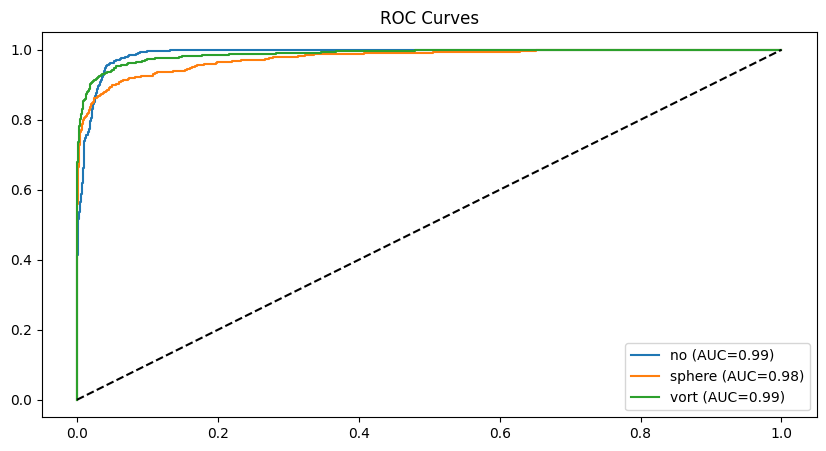

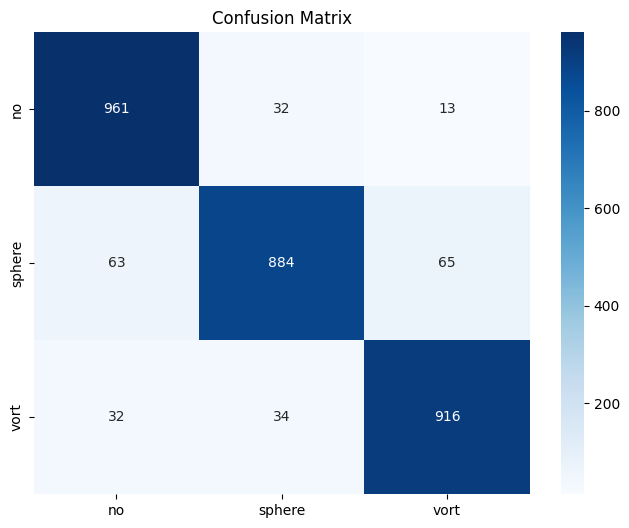

In [ ]:

# Setup Data (Update DATA_DIR as needed)
DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/train'
full_dataset = GravitationalLensingDataset(DATA_DIR, transform=data_transforms['train'])
train_size = int(0.9 * len(full_dataset))
train_ds, val_ds = random_split(full_dataset, [train_size, len(full_dataset) - train_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Initialize Model
model = PINNLensingModelHybrid().to(DEVICE)
load_custom_weights(model, RESNET_WEIGHTS_PATH, EFFNET_WEIGHTS_PATH)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
best_acc = 0.0

# Training Loop
for epoch in range(NUM_EPOCHS):
    if epoch < WARMUP_EPOCHS:
        print(f"--- Epoch {epoch+1}/{NUM_EPOCHS} (Warm-up Mode) ---")
        model.parameter_encoder.eval()
        for param in model.parameter_encoder.parameters(): param.requires_grad = False
    else:
        print(f"--- Epoch {epoch+1}/{NUM_EPOCHS} (Full Training) ---")
        model.parameter_encoder.train()
        for param in model.parameter_encoder.parameters(): param.requires_grad = True
    
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Evaluation
    model.eval()
    all_labels, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels, all_probs, all_preds = np.array(all_labels), np.array(all_probs), np.array(all_preds)
    accuracy = (all_preds == all_labels).mean()
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    
    print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {auc_score:.4f}")

    if accuracy > best_acc:
        best_acc = accuracy
        torch.save(model.state_dict(), 'phy_hybrid_best_model.pt')
        print("New best model saved!")

# --- Final Visualization ---
def plot_results(labels, probs, preds, classes):
    # ROC Curve
    plt.figure(figsize=(10, 5))
    for i, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve((labels == i).astype(int), probs[:, i])
        plt.plot(fpr, tpr, label=f'{class_name} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title('ROC Curves')
    plt.legend()
    plt.savefig("roc_auc_new.png")
    plt.show()

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(labels, preds), annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.savefig("cm_new.png")
    plt.show()

plot_results(all_labels, all_probs, all_preds, full_dataset.classes)

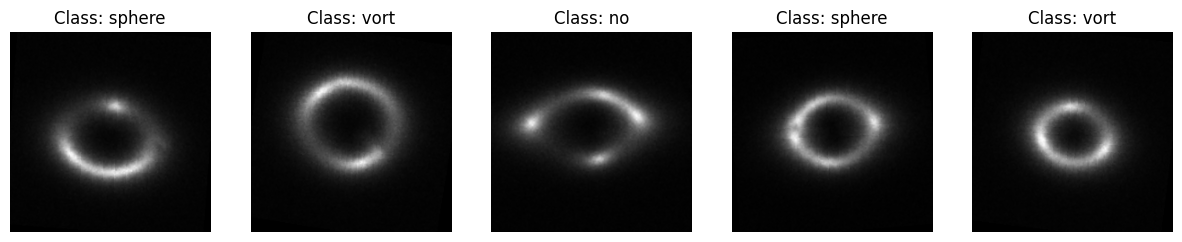

In [ ]:
def visualize_original_batch(dataloader, classes, n=5):
    images, labels = next(iter(dataloader))
    plt.figure(figsize=(15, 5))
    for i in range(n):
        img = images[i][:3].cpu().numpy().transpose(1, 2, 0)
        img = (img * 0.5) + 0.5  # Un-normalize
        plt.subplot(1, n, i+1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f"Class: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()


visualize_original_batch(train_loader, full_dataset.classes)

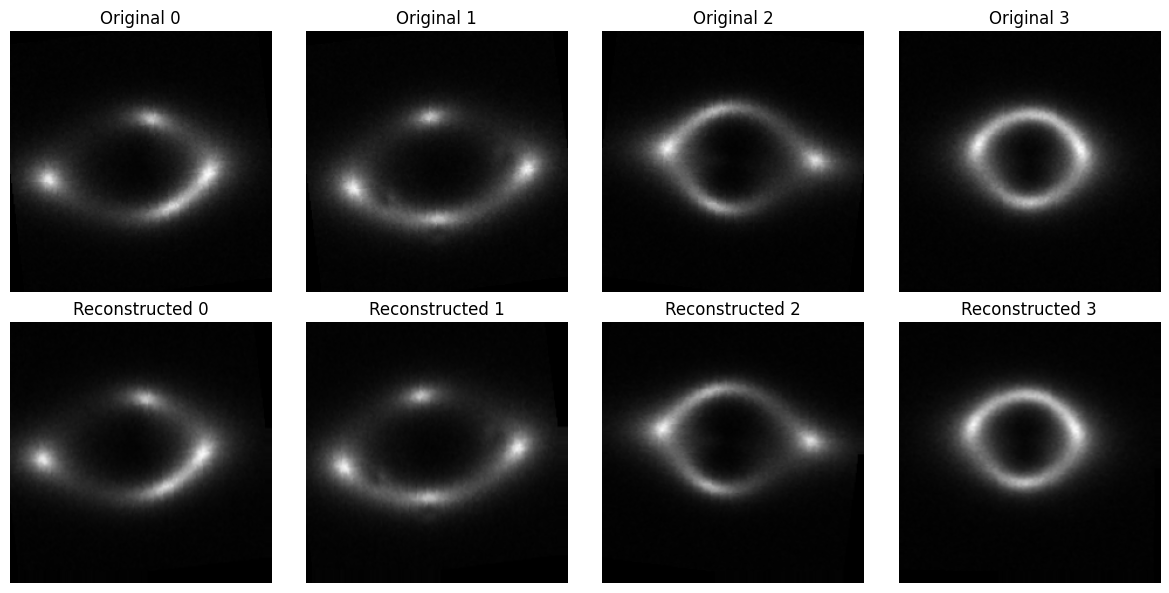

In [ ]:
def visualize_reconstructions(model, dataloader, device, n=4):
    model.eval()
    images, labels = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        
        alpha = model.parameter_encoder(images)
        reconstructed = model.lensing_layer(images, alpha)
    
    plt.figure(figsize=(12, 6))
    for i in range(n):
        
        img_orig = images[i].cpu().numpy().transpose(1, 2, 0)
        img_orig = (img_orig * 0.5) + 0.5
        
        
        img_recon = reconstructed[i].cpu().numpy().transpose(1, 2, 0)
        img_recon = (img_recon * 0.5) + 0.5
        
        plt.subplot(2, n, i + 1)
        plt.imshow(np.clip(img_orig, 0, 1))
        plt.title(f"Original {i}")
        plt.axis('off')
        
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(np.clip(img_recon, 0, 1))
        plt.title(f"Reconstructed {i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


visualize_reconstructions(model, val_loader, DEVICE)

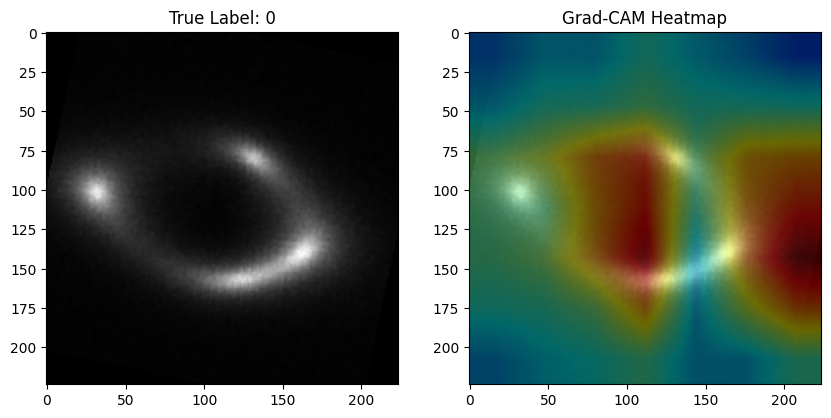

In [ ]:
import torch.nn.functional as F
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, class_idx=None):
        # Forward pass
        output = self.model(input_image)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

def display_gradcam(model, image_tensor, label):
    # targetting the last layer of the efficientnet-b0
    target_layer = model.classifier.features[-1]
    gad_cam = GradCAM(model, target_layer)
    
    input_batch = image_tensor.unsqueeze(0).to(DEVICE)
    heatmap = gad_cam.generate_heatmap(input_batch)
    
    img = image_tensor[:3].cpu().numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5
    
    
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    superimposed_img = heatmap_color * 0.4 + img * 255 * 0.6
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"True Label: {label}")
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.title("Grad-CAM Heatmap")
    plt.show()

single_img, single_lbl = val_ds[0]
display_gradcam(model, single_img, single_lbl)

In [ ]:
NUM_CLASSES = 3
BATCH_SIZE = 64 
LEARNING_RATE = 0.0001
NUM_EPOCHS = 15
WARMUP_EPOCHS = 5
IMAGE_SIZE = 224
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Path to the single best model weights saved from my previous run
COMBINED_WEIGHTS_PATH = '/kaggle/input/datasets/adman007/approach-1-retrained/phy_hybrid_best_model.pt' 


In [ ]:
class LensingLayer(nn.Module):
    def __init__(self, img_size=224):
        super(LensingLayer, self).__init__()
        self.img_size = img_size
        x = torch.linspace(-1, 1, img_size)
        y = torch.linspace(-1, 1, img_size)
        grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
        self.register_buffer('grid', torch.stack((grid_y, grid_x), dim=-1).unsqueeze(0)) 

    def forward(self, x, alpha):
        batch_size = x.size(0)
        shift = (alpha * 0.05).view(batch_size, 1, 1, 2) 
        recon_grid = self.grid.expand(batch_size, -1, -1, -1) - shift
        source_recon = nn.functional.grid_sample(x, recon_grid, align_corners=True, padding_mode='border')
        return source_recon

class PINNLensingModelHybrid(nn.Module):
    def __init__(self):
        super(PINNLensingModelHybrid, self).__init__()
        
        # 1. Encoder (ResNet-34)
        self.parameter_encoder = models.resnet34(weights=None)
        self.parameter_encoder.fc = nn.Linear(self.parameter_encoder.fc.in_features, 2)
        
        self.lensing_layer = LensingLayer(img_size=IMAGE_SIZE)
        
        # 2. Classifier (EfficientNet-B0)
        self.classifier = models.efficientnet_b0(weights=None)
        
        # Modify first layer for 6 channels (3 obs + 3 recon)
        original_conv = self.classifier.features[0][0]
        self.classifier.features[0][0] = nn.Conv2d(
            6, original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )
        self.classifier.classifier[1] = nn.Linear(self.classifier.classifier[1].in_features, NUM_CLASSES)

    def forward(self, x):
        alpha = self.parameter_encoder(x)
        source_recon = self.lensing_layer(x, alpha)
        combined_input = torch.cat((x, source_recon), dim=1) 
        return self.classifier(combined_input)



def load_unified_weights(model, path):
    if not os.path.exists(path):
        print(f"Error: Unified weights not found at {path}. Check your path.")
        return

    print(f"Loading unified hybrid model weights from: {path}")
    state_dict = torch.load(path, map_location=DEVICE)
    

    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("_orig_mod.", "") 
        new_state_dict[name] = v
        
    model.load_state_dict(new_state_dict)
    print("Full hybrid model weights loaded successfully.")



class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float().repeat(3, 1, 1)
        if self.transform: image = self.transform(image)
        return image, label

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
        transforms.RandomRotation(15), transforms.RandomHorizontalFlip(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ]),
    "val": transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
}


Loading unified hybrid model weights from: /kaggle/input/datasets/adman007/approach-1-retrained/phy_hybrid_best_model.pt
Full hybrid model weights loaded successfully.
--- Epoch 1/15 (Warm-up Mode: Encoder Frozen) ---


100%|██████████| 422/422 [00:42<00:00,  9.96it/s]


Accuracy: 0.8837 | ROC-AUC: 0.97728
New best version saved!
--- Epoch 2/15 (Warm-up Mode: Encoder Frozen) ---


100%|██████████| 422/422 [00:32<00:00, 12.89it/s]


Accuracy: 0.9347 | ROC-AUC: 0.99040
New best version saved!
--- Epoch 3/15 (Warm-up Mode: Encoder Frozen) ---


...

Accuracy: 0.9247 | ROC-AUC: 0.98896
--- Epoch 14/15 (Full Training: All Unfrozen) ---


100%|██████████| 422/422 [00:32<00:00, 13.14it/s]


Accuracy: 0.9440 | ROC-AUC: 0.99150
--- Epoch 15/15 (Full Training: All Unfrozen) ---


100%|██████████| 422/422 [00:32<00:00, 13.10it/s]


Accuracy: 0.9447 | ROC-AUC: 0.99122


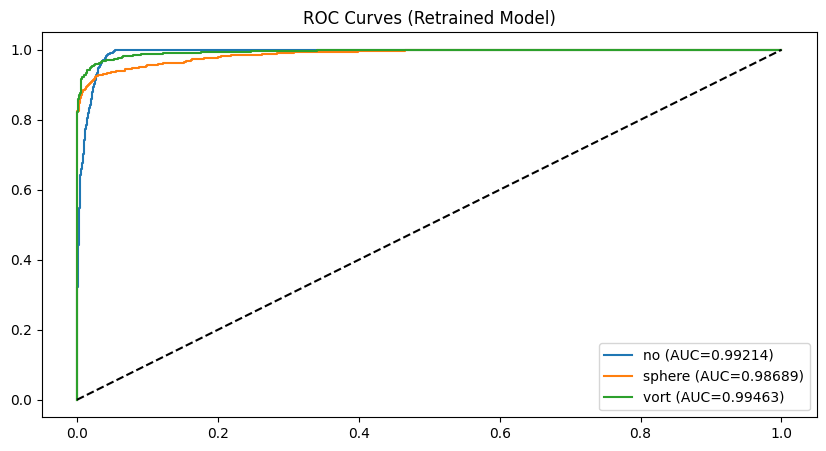

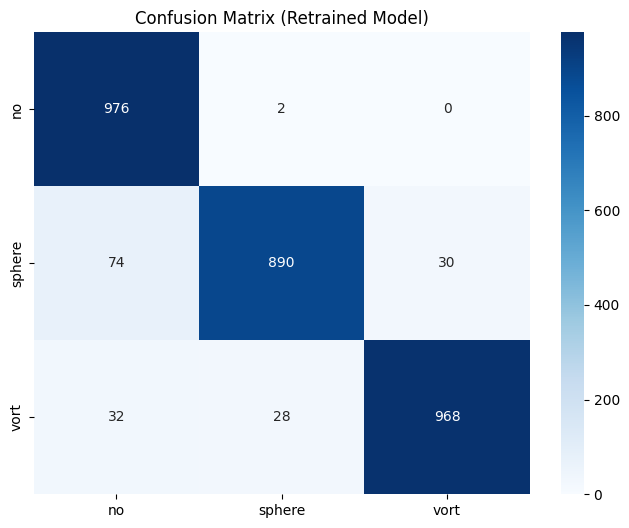

In [ ]:
DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/train'
full_dataset = GravitationalLensingDataset(DATA_DIR, transform=data_transforms['train'])
train_size = int(0.9 * len(full_dataset))
train_ds, val_ds = random_split(full_dataset, [train_size, len(full_dataset) - train_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


model = PINNLensingModelHybrid().to(DEVICE)
load_unified_weights(model, COMBINED_WEIGHTS_PATH)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
best_acc = 0.0


for epoch in range(NUM_EPOCHS):
    # Warm-up Logic
    if epoch < WARMUP_EPOCHS:
        print(f"--- Epoch {epoch+1}/{NUM_EPOCHS} (Warm-up Mode: Encoder Frozen) ---")
        model.parameter_encoder.eval()
        for param in model.parameter_encoder.parameters(): param.requires_grad = False
    else:
        print(f"--- Epoch {epoch+1}/{NUM_EPOCHS} (Full Training: All Unfrozen) ---")
        model.parameter_encoder.train()
        for param in model.parameter_encoder.parameters(): param.requires_grad = True
    
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    
    model.eval()
    all_labels, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels, all_probs, all_preds = np.array(all_labels), np.array(all_probs), np.array(all_preds)
    accuracy = (all_preds == all_labels).mean()
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    
    print(f"Accuracy: {accuracy:.4f} | ROC-AUC: {auc_score:.5f}")

    if accuracy > best_acc:
        best_acc = accuracy
        torch.save(model.state_dict(), 'phy_hybrid_best_model_v2.pt')
        print("New best version saved!")

# Visualization Function
def plot_results(labels, probs, preds, classes):
    plt.figure(figsize=(10, 5))
    for i, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve((labels == i).astype(int), probs[:, i])
        plt.plot(fpr, tpr, label=f'{class_name} (AUC={auc(fpr, tpr):.5f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title('ROC Curves (Retrained Model)')
    plt.legend()
    plt.savefig("roc_auc_retrained.png")
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(labels, preds), annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (Retrained Model)')
    plt.savefig("cm_retrained.png")
    plt.show()

plot_results(all_labels, all_probs, all_preds, full_dataset.classes)